# Regression

In [34]:
# importing essential libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [14]:
df = pd.read_csv(r"D:\git things\Machine-Vision-Projects\Datasets\house-price-prediction\house_prices_practice.csv")
df.head(5)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [16]:
# Good features usually have: correlation| > 0.3
corr = df.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
GrLivArea       0.745095
OverallQual     0.352899
GarageCars      0.351321
FullBath        0.273731
TotalBsmtSF     0.250178
YearBuilt       0.222142
BedroomAbvGr    0.014113
Id             -0.025416
LotArea        -0.038982
Name: SalePrice, dtype: float64

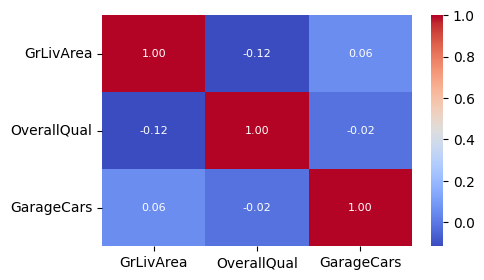

In [ ]:
df_ = df[["GrLivArea", "OverallQual", "GarageCars"]]
# If two features are very correlated: corr > 0.85, keep only one.
plt.figure(figsize=(5,3))
sns.heatmap(
    df_.corr(),
    annot=True,           # show correlation values
    fmt=".2f",            # show 2 decimal places
    cmap="coolwarm",      # change color map
    annot_kws={"size":8}  # make numbers smaller
)
plt.show()

In [ ]:
# it is usually better to normalize (scale) the features.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_)

### Normal Equation (Closed-Form Solution)

$$
y = w_0 + w_1x_1 + w_2x_2 + w_3x_3 \\
Xw = y
$$
$$
\begin{bmatrix}
1 & x_{11} & x_{12} & x_{13} \\
1 & x_{21} & x_{22} & x_{23} \\
1 & x_{31} & x_{32} & x_{33} \\
. & . & . & . \\
. & . & . & .
\end{bmatrix}
\begin{bmatrix}
w_0 \\
w_1 \\
w_2 \\
w_3
\end{bmatrix}
=
\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
. \\
.
\end{bmatrix}
$$
The regression solution is
$$
w = (X^T X)^{-1} X^T y
$$

In [37]:
df_X = df_scaled
df_y = df["SalePrice"]
X = np.c_[np.ones(df_X.shape[0]), df_X]
y = df_y.values
XT = X.T
w = np.linalg.inv(XT @ X) @ XT @ y
print(w)

[252262.90333333  58371.47324521  33622.08527511  23589.62147796]
